In [1]:
import pandas as pd
# df = pd.read_csv("mismatches/mismatches_merged.csv")
df = pd.read_parquet("31032026_olej_inny.parquet")
df = df[df['Device_Type'] == 'Sil']

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from parser import parser

In [3]:
df

,Lab_Number,Sample_Condition,Sample_Type,Is_Feng,Client,Client_Device,Device_Type,Subtype,Manufacturer,Capacity,...,RPVOT_delta_p_above_1440,Corrosive_sulfur_ASTM,Fuel_content,Kinematic_viscosity_at_0C,Kinematic_viscosity_at_80C,Kinematic_viscosity_at_110C,Density_at_15_5C,Density_at_50C,Breakdown_voltage_ASTM,Standard_deviation_of_breakdown_voltage_ASTM
152,P1304884,None,None,False,13239,Silnik Gazowy,Sil,GAZOWY,GE JENBACHER,600.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
215,P1305076,None,None,False,11112,5794/ZL/13,Sil,None,brak danych,0.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
263,P1400113,None,None,False,10194,2D5155,Sil,None,POLARTECHNIK PMC OY AB,250.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
360,P1400354,None,None,False,13239,Silnik Gazowy,Sil,GAZOWY,GE JENBACHER,600.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
404,P1400417,None,None,False,10502,Silnik,Sil,None,brak danych,50.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160427,P2605122,nieprzejrzysty; Pojemnik PET 200ml,Przemysłowe oleje smarowe,True,24658,SM42-645,Sil,None,brak danych,NaN,...,None,NaN,2.2,NaN,NaN,None,NaN,NaN,NaN,NaN
160433,P2605167,Pojemnik PET 200ml; nieprzejrzysty,Przemysłowe oleje smarowe,True,35368,KALMAR DCG100-6 FL 337 - silnik,Sil,None,KALMAR CARGOTEC,16.0,...,None,NaN,"<2,0",NaN,NaN,None,NaN,NaN,NaN,NaN
160434,P2605169,nieprzejrzysty; Pojemnik PET 200ml,Przemysłowe oleje smarowe,True,35368,TERBERG YT 223 TR 253 - silnik,Sil,None,TERBERG,17.0,...,None,NaN,2.8,NaN,NaN,None,NaN,NaN,NaN,NaN
160435,P2605173,Pojemnik PET 200ml; nieprzejrzysty,Przemysłowe oleje smarowe,False,39486,SP-FCP,Sil,Tłokowy - lotniczy,Rotax,3.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN


In [4]:
data = parser.df_to_json(df, 0, len(df))
data

{'P1304884': {'metale_zużyciowe': 'w_normie',
  'lepkość': 'w_normie',
  'woda': 'w_normie',
  'liczba_kwasowa': 'w_normie',
  'ph': 'w_normie',
  'dodatki_uszlachetniające': 'w_normie'},
 'P1305076': {},
 'P1400113': {},
 'P1400354': {'miedź': 'podniesiony',
  'sód': 'obniżony',
  'krzem': 'obniżony',
  'lepkość': 'w_normie',
  'ph': 'w_normie',
  'liczba_kwasowa': 'w_normie',
  'liczba_zasadowa': 'obniżony',
  'trend_liczba_zasadowa': 'w_normie'},
 'P1400417': {'żelazo': 'lekko_podniesiony',
  'dodatki_uszlachetniające': 'w_normie',
  'lepkość': 'w_normie',
  'liczba_kwasowa': 'w_normie'},
 'P1400044': {'miedź': 'lekko_podniesiony',
  'lepkość': 'w_normie',
  'liczba_kwasowa': 'krytycznie_obniżony'},
 'P1305077': {},
 'P1400480': {},
 'P1400482': {},
 'P1400184': {'metale_zużyciowe': 'w_normie',
  'sód': 'obniżony',
  'krzem': 'obniżony',
  'lepkość': 'w_normie',
  'ph': 'w_normie',
  'liczba_kwasowa': 'w_normie',
  'liczba_zasadowa': 'obniżony'},
 'P1400003': {'miedź': 'lekko_podnie

In [8]:
# Słownik porządkujący statusy na osi "odchyłu"
STATUS_TO_ABNORMALITY = {
    # brak wiarygodnego wyniku
    "nieoznaczono": None,

    # brak wykrycia / norma
    "brak_wykrycia": 0.0,
    "w_normie": 0.0,
    "w_zakresie_typowym": 0.0,
    "w_zakresie_bezpiecznym": 0.0,
    "w_akceptowalnym_zakresie": 0.0,
    "w_dopuszczalnym_zakresie": 0.0,

    # graniczne / bardzo lekkie odchylenie
    "w_zakresie_granicznym": 0.0,
    "nieznacznie_odbiega": 0.0,

    # lekkie / małe odchylenie
    "nieznacznie_podniesiony": 0.5,
    "nieznacznie_obniżony": 0.5,
    "lekko_podniesiony": 0.5,
    "lekko_obniżony": 0.5,
    "podniesiony": 0.5,
    "obniżony": 0.5,
    "powyżej_typowego": 0.5,
    "poniżej_typowego": 0.5,
    "nietypowy": 0.5,
    "pogorszony": 0.5,
    "wysoki": 0.5,
    "poza_dopuszczalnym_zakresem": 0.5,
    "powyżej_dopuszczalnego_limitu": 0.5,

    "wzrostowy": 0.5,
    

    # wyraźne odchylenie
    "znacznie_podniesiony": 1.0,
    "znacznie_obniżony": 1.0,
    "mocno_podwyższony": 1.0,
    "mocno_obniżony": 1.0,
    "mocno_pogorszony": 1.0,


    # krytyczne
    "krytycznie_podniesiony": 1.0,
    "krytycznie_obniżony": 1.0,
}

abnormality,0.0,0.5,1.0,abnormal_total
key,,,,
miedź,21689,1841,485,2326
lepkość,21858,1963,194,2157
temperatura_zapłonu,21899,1726,390,2116
paliwo,22568,1218,229,1447
sód,22717,1111,187,1298
...,...,...,...,...
oznaczone_parametry,24015,0,0,0
pozostałe_parametry,24015,0,0,0
trend_sulfacja,24015,0,0,0


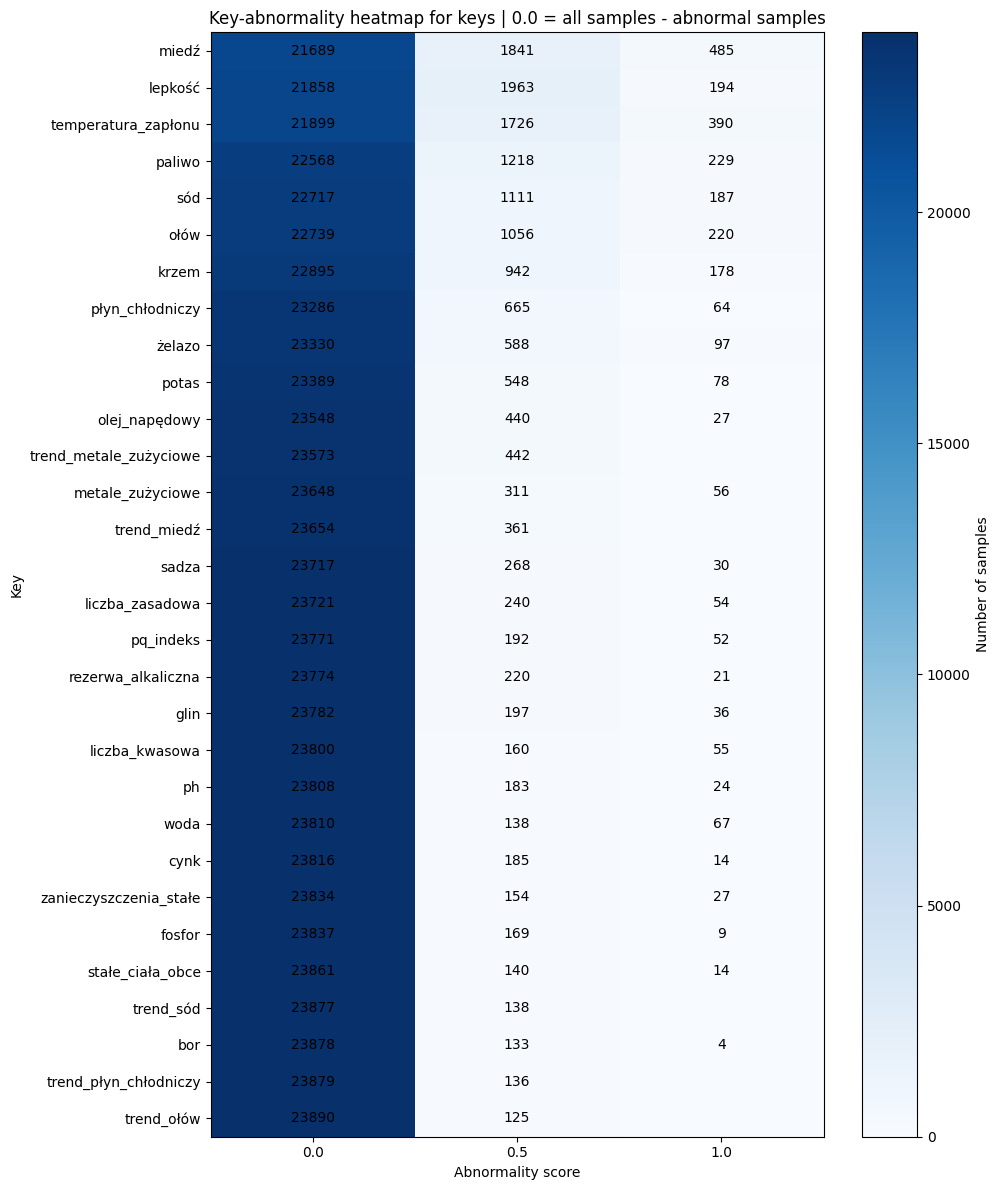


Total samples used for implicit 0.0: 24015

Unknown values not found in STATUS_TO_ABNORMALITY:


,value,count
0,spadkowy,440
1,do_obserwacji,107
2,odbiega_od_referencji,3



Values skipped because they are mapped to None:


,value,count
0,nieoznaczono,14


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ============================================================
# SETTINGS
# ============================================================

KEY_MODE = "all"              # "all" or "trend"
TOP_N_KEYS = 30

USE_IMPLICIT_ZERO = True      # if True: 0.0 = all samples - abnormal samples for this key
SHOW_ZERO_COL = True          # if False: compute 0.0 but do not plot it

TOTAL_SAMPLE_MODE = "all"     # "all" or "with_any_keys"
FIG_WIDTH = 10


# ============================================================
# HELPERS
# ============================================================

def should_use_key(key, key_mode):
    if key_mode == "all":
        return True

    if key_mode == "trend":
        return str(key).startswith("trend_")

    raise ValueError("KEY_MODE must be either 'all' or 'trend'")


def get_total_sample_count(data, mode="all"):
    if mode == "all":
        return len(data)

    if mode == "with_any_keys":
        return sum(
            isinstance(values, dict) and len(values) > 0
            for values in data.values()
        )

    raise ValueError("TOTAL_SAMPLE_MODE must be either 'all' or 'with_any_keys'")


def filter_columns_for_plot(matrix, show_zero=True):
    cols_to_keep = []

    for col in matrix.columns:
        if col == "abnormal_total":
            continue

        if not show_zero and col == 0.0:
            continue

        cols_to_keep.append(col)

    return matrix[cols_to_keep]


# ============================================================
# BUILD LONG DATAFRAME
# ============================================================

rows = []
unknown_values = Counter()
skipped_none_values = Counter()

total_samples = get_total_sample_count(data, TOTAL_SAMPLE_MODE)

for lab_number, values in data.items():
    if not isinstance(values, dict) or len(values) == 0:
        continue

    for key, value in values.items():
        if not should_use_key(key, KEY_MODE):
            continue

        if value not in STATUS_TO_ABNORMALITY:
            unknown_values[value] += 1
            continue

        abnormality = STATUS_TO_ABNORMALITY[value]

        if abnormality is None:
            skipped_none_values[value] += 1
            continue

        rows.append({
            "Lab_Number": lab_number,
            "key": key,
            "value": value,
            "abnormality": abnormality,
        })


long_df = pd.DataFrame(rows)


# ============================================================
# BUILD HEATMAP MATRIX
# ============================================================

if long_df.empty:
    print("No matching key/value combinations found.")

else:
    heatmap_df = (
        long_df
        .assign(count=1)
        .pivot_table(
            index="key",
            columns="abnormality",
            values="count",
            aggfunc="sum",
            fill_value=0,
        )
    )

    # Ensure standard abnormality columns exist
    for col in [0.0, 0.5, 1.0]:
        if col not in heatmap_df.columns:
            heatmap_df[col] = 0

    # Sort columns numerically
    heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)

    if USE_IMPLICIT_ZERO:
        # Only abnormal columns count as "key is present as abnormal"
        abnormal_cols = [col for col in heatmap_df.columns if col != 0.0]

        abnormal_count = heatmap_df[abnormal_cols].sum(axis=1)

        # 0.0 means: all samples minus samples where this key has abnormal value
        heatmap_df[0.0] = total_samples - abnormal_count

        # Safety: avoid negative values
        heatmap_df[0.0] = heatmap_df[0.0].clip(lower=0).astype(int)

    # Sort columns again because 0.0 was overwritten
    heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)

    # Sort rows by abnormal samples only, not by implicit normal count
    abnormal_cols = [col for col in heatmap_df.columns if col != 0.0]
    heatmap_df["abnormal_total"] = heatmap_df[abnormal_cols].sum(axis=1)

    heatmap_df = heatmap_df.sort_values("abnormal_total", ascending=False)

    display(heatmap_df)


    # ============================================================
    # PLOT
    # ============================================================

    heatmap_plot = filter_columns_for_plot(
        heatmap_df,
        show_zero=SHOW_ZERO_COL,
    ).head(TOP_N_KEYS)

    if heatmap_plot.empty:
        print("No columns selected for plotting.")

    else:
        fig_height = max(6, 0.4 * len(heatmap_plot))
        plt.figure(figsize=(FIG_WIDTH, fig_height))

        im = plt.imshow(heatmap_plot.values, aspect="auto", cmap="Blues")

        plt.colorbar(im, label="Number of samples")

        plt.xticks(
            ticks=range(len(heatmap_plot.columns)),
            labels=heatmap_plot.columns,
            rotation=0,
        )

        plt.yticks(
            ticks=range(len(heatmap_plot.index)),
            labels=heatmap_plot.index,
        )

        # Add numbers inside cells
        for i in range(len(heatmap_plot.index)):
            for j in range(len(heatmap_plot.columns)):
                cell_value = heatmap_plot.iloc[i, j]

                if cell_value > 0:
                    plt.text(
                        j,
                        i,
                        str(int(cell_value)),
                        ha="center",
                        va="center",
                    )

        title_key_part = "trend keys" if KEY_MODE == "trend" else "keys"

        title_parts = [f"Key-abnormality heatmap for {title_key_part}"]

        if USE_IMPLICIT_ZERO:
            title_parts.append("0.0 = all samples - abnormal samples")

        plt.title(" | ".join(title_parts))
        plt.xlabel("Abnormality score")
        plt.ylabel("Key")
        plt.tight_layout()
        plt.show()


# ============================================================
# DIAGNOSTICS
# ============================================================

print(f"\nTotal samples used for implicit 0.0: {total_samples}")

if unknown_values:
    print("\nUnknown values not found in STATUS_TO_ABNORMALITY:")
    display(
        pd.DataFrame(
            unknown_values.items(),
            columns=["value", "count"]
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

if skipped_none_values:
    print("\nValues skipped because they are mapped to None:")
    display(
        pd.DataFrame(
            skipped_none_values.items(),
            columns=["value", "count"]
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

In [10]:
import pandas as pd
from collections import Counter

# ============================================================
# SETTINGS
# ============================================================

TOP_N_KEYS = 100
KEY_MODE = "all"  # "all" or "trend"

OUTPUT_ZERO_FOR_MISSING_KEY = True
# True  -> if sample does not have this key, put 0.0
# False -> if sample does not have this key, put NaN


# ============================================================
# HELPERS
# ============================================================

def should_use_key(key, key_mode):
    if key_mode == "all":
        return True

    if key_mode == "trend":
        return str(key).startswith("trend_")

    raise ValueError("KEY_MODE must be either 'all' or 'trend'")


def value_to_score(value):
    """
    Convert parser value directly using STATUS_TO_ABNORMALITY.

    Expected output:
    - 0.0
    - 0.5
    - 1.0
    - pd.NA for unknown / skipped values
    """
    if value not in STATUS_TO_ABNORMALITY:
        return pd.NA

    score = STATUS_TO_ABNORMALITY[value]

    if score is None:
        return pd.NA

    return score


# ============================================================
# FIND TOP N MOST POPULAR KEYS
# ============================================================

key_counter = Counter()

for lab_number, values in data.items():
    if not isinstance(values, dict) or len(values) == 0:
        continue

    for key in values.keys():
        if should_use_key(key, KEY_MODE):
            key_counter[key] += 1

top_keys = [key for key, count in key_counter.most_common(TOP_N_KEYS)]

print("Top keys:")
for key in top_keys:
    print(f"{key}: {key_counter[key]}")


# ============================================================
# BUILD FEATURES DATAFRAME
# ============================================================

rows = []
unknown_values = Counter()
skipped_none_values = Counter()

for lab_number, values in data.items():
    row = {"Lab_Number": str(lab_number)}

    if not isinstance(values, dict):
        values = {}

    for key in top_keys:
        if key in values:
            raw_value = values[key]

            if raw_value not in STATUS_TO_ABNORMALITY:
                unknown_values[raw_value] += 1
                score = pd.NA
            elif STATUS_TO_ABNORMALITY[raw_value] is None:
                skipped_none_values[raw_value] += 1
                score = pd.NA
            else:
                score = STATUS_TO_ABNORMALITY[raw_value]

        else:
            score = 0.0 if OUTPUT_ZERO_FOR_MISSING_KEY else pd.NA

        row[key] = score

    rows.append(row)

features_df = pd.DataFrame(rows)
features_df = features_df[["Lab_Number"] + top_keys]


# ============================================================
# ADD OVERALL_ASSESSMENT TARGET FROM df
# ============================================================

ASSESSMENT_MAP = {
    "W NORMIE": 0,
    "WSKAZÓWKA": 1,
    "UWAGA": 2,
}

assessment_df = df[["Lab_Number", "Overall_Assessment"]].copy()

assessment_df["Lab_Number"] = assessment_df["Lab_Number"].astype(str)

assessment_df["Overall_Assessment_clean"] = (
    assessment_df["Overall_Assessment"]
    .astype(str)
    .str.strip()
    .str.upper()
)

assessment_df["Overall_Assessment_mapped"] = (
    assessment_df["Overall_Assessment_clean"]
    .map(ASSESSMENT_MAP)
)

features_df = features_df.merge(
    assessment_df[["Lab_Number", "Overall_Assessment", "Overall_Assessment_mapped"]],
    on="Lab_Number",
    how="left",
)


# ============================================================
# DISPLAY
# ============================================================

display(features_df)

print("Shape:", features_df.shape)

print("\nOverall_Assessment_mapped counts:")
display(
    features_df["Overall_Assessment_mapped"]
    .value_counts(dropna=False)
    .sort_index()
)

if unknown_values:
    print("\nUnknown values not found in STATUS_TO_ABNORMALITY:")
    display(
        pd.DataFrame(
            unknown_values.items(),
            columns=["value", "count"]
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

if skipped_none_values:
    print("\nValues skipped because they are mapped to None:")
    display(
        pd.DataFrame(
            skipped_none_values.items(),
            columns=["value", "count"]
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

Top keys:
lepkość: 12455
temperatura_zapłonu: 11096
metale_zużyciowe: 10771
woda: 6085
liczba_zasadowa: 5743
płyn_chłodniczy: 3722
oznaczone_parametry: 3313
paliwo: 3219
pq_indeks: 3014
miedź: 2513
pozostałe_parametry: 2116
stałe_ciała_obce: 1753
zanieczyszczenia_stałe: 1569
ołów: 1344
sód: 1316
olej_napędowy: 1265
wskaźnik_lepkości: 1197
krzem: 1195
rezerwa_alkaliczna: 1023
liczba_kwasowa: 852
trend_miedź: 827
żelazo: 737
glikol: 721
trend_metale_zużyciowe: 668
ph: 644
potas: 629
sadza: 477
oksydacja: 460
nitracja: 328
trend_lepkość: 307
trend_sód: 285
klasa_czystości: 263
dodatki_uszlachetniające: 258
glin: 258
trend_ołów: 215
cynk: 206
trend_żelazo: 195
fosfor: 183
trend_krzem: 173
trend_płyn_chłodniczy: 173
sulfacja: 138
bor: 138
trend_cynk: 113
trend_ogólny: 107
cyna: 107
trend_potas: 106
trend_paliwo: 105
własności_filtrujące: 105
trend_fosfor: 101
trend_liczba_zasadowa: 73
trend_temperatura_zapłonu: 64
trend_glin: 49
trend_zanieczyszczenia_stałe: 48
trend_bor: 43
pozostałość_po_

,Lab_Number,lepkość,temperatura_zapłonu,metale_zużyciowe,woda,liczba_zasadowa,płyn_chłodniczy,oznaczone_parametry,paliwo,pq_indeks,...,trend_wskaźnik_lepkości,trend_rezerwa_alkaliczna,trend_biokomponenty,trend_sulfacja,trend_temperatura_krystalizacji,trend_magnez,trend_pozostałość_po_spopieleniu,trend_azotyny,Overall_Assessment,Overall_Assessment_mapped
0,P1304884,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,W NORMIE,0.0
1,P1305076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BRAK,NaN
2,P1400113,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,W NORMIE,0.0
3,P1400354,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WSKAZÓWKA,1.0
4,P1400417,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WSKAZÓWKA,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24011,P2605122,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,W NORMIE,0.0
24012,P2605167,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WSKAZÓWKA,1.0
24013,P2605169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,W NORMIE,0.0
24014,P2605173,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,W NORMIE,0.0


Shape: (24016, 85)

Overall_Assessment_mapped counts:


Overall_Assessment_mapped
0.0    12419
1.0     6551
2.0     3160
NaN     1886
Name: count, dtype: int64


Unknown values not found in STATUS_TO_ABNORMALITY:


,value,count
0,spadkowy,440
1,do_obserwacji,107
2,odbiega_od_referencji,3



Values skipped because they are mapped to None:


,value,count
0,nieoznaczono,14


In [11]:
features_df.to_csv("explanations.csv", index=False)